In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 99% 1.01G/1.03G [00:09<00:00, 170MB/s]
100% 1.03G/1.03G [00:10<00:00, 110MB/s]


In [ ]:
!unzip -q asl-alphabet.zip -d asl_alphabet_data

In [ ]:
import os

# List a few files from the training set
base_path = "asl_alphabet_data/asl_alphabet_train/asl_alphabet_train"
print(os.listdir(base_path)[:5])  # shows first 5 letter folders


['J', 'A', 'E', 'W', 'K']


In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data_dir = "asl_alphabet_data/asl_alphabet_train/asl_alphabet_train"
batch_size = 64
img_size = 224
epochs = 10
learning_rate = 1e-4

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

In [ ]:
num_classes

29

In [ ]:
class_names

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'del',
 'nothing',
 'space']

In [ ]:
dataset

Dataset ImageFolder
    Number of datapoints: 87000
    Root location: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 69600
Validation set size: 17400


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [ ]:
def imshow(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))      # Convert from [C,H,W] to [H,W,C]
    img = img * 0.5 + 0.5                               # Undo normalization
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')


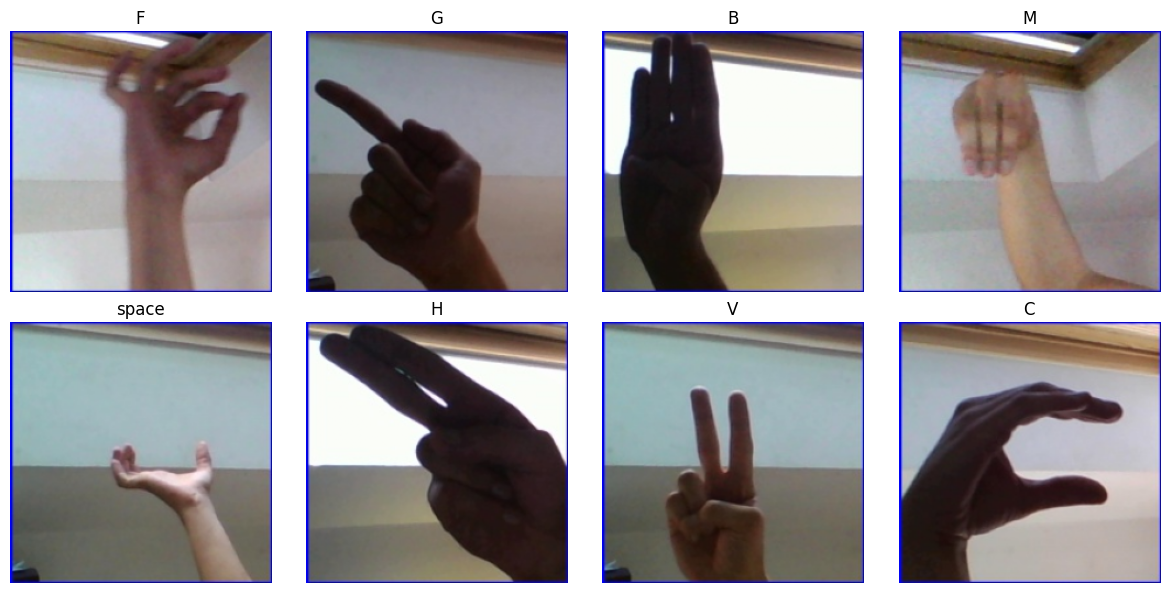

In [ ]:
images, labels = next(iter(train_loader))


class_names = dataset.classes


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i], title=class_names[labels[i]])
plt.tight_layout()
plt.show()


In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
from tqdm import tqdm

best_val_acc = 0.0
save_path = 'best_model.pth'

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs.to(device))
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels.to(device)).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"\nEpoch {epoch+1}: Val Accuracy = {val_acc:.4f}, Loss = {running_loss/len(train_loader):.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print("✅ Best model saved!")


Epoch 1/10: 100%|██████████| 1088/1088 [06:13<00:00,  2.91it/s]



Epoch 1: Val Accuracy = 0.9999, Loss = 0.0037
✅ Best model saved!


Epoch 2/10: 100%|██████████| 1088/1088 [06:12<00:00,  2.92it/s]



Epoch 2: Val Accuracy = 1.0000, Loss = 0.0004
✅ Best model saved!


Epoch 3/10: 100%|██████████| 1088/1088 [06:08<00:00,  2.95it/s]


...


Epoch 8: Val Accuracy = 1.0000, Loss = 0.0000


Epoch 9/10: 100%|██████████| 1088/1088 [06:10<00:00,  2.94it/s]



Epoch 9: Val Accuracy = 1.0000, Loss = 0.0000


Epoch 10/10: 100%|██████████| 1088/1088 [06:10<00:00,  2.94it/s]



Epoch 10: Val Accuracy = 1.0000, Loss = 0.0000


In [ ]:
from PIL import Image

class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
               'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
               'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
label_to_index = {label: idx for idx, label in enumerate(class_names)}

test_dir = "/content/asl_alphabet_data/asl_alphabet_test/asl_alphabet_test"
test_images = []
image_paths = []
labels = []

for filename in os.listdir(test_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        label_char = filename[0].upper()
        if label_char in label_to_index:
            labels.append(label_to_index[label_char])
            img_path = os.path.join(test_dir, filename)
            image = Image.open(img_path).convert('RGB')
            image = transform(image)
            test_images.append(image)
            image_paths.append(filename)

In [ ]:
labels

[18,
 18,
 20,
 24,
 14,
 6,
 1,
 10,
 3,
 12,
 15,
 4,
 21,
 2,
 8,
 22,
 5,
 25,
 0,
 19,
 23,
 16,
 17,
 11,
 13,
 9,
 7,
 13]

In [ ]:
from torch.utils.data import TensorDataset, DataLoader


test_tensor = torch.stack(test_images)

label_tensor = torch.tensor(labels)

test_dataset = TensorDataset(test_tensor, label_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
test_loader

In [ ]:
# Load best weights
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Evaluate on test set
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9286


<Figure size 1200x2500 with 0 Axes>

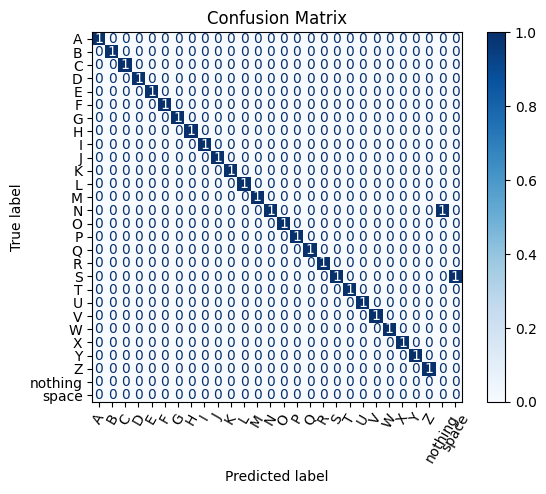

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 25))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=60, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()